В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

***
1.
---

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [18]:
def normal_equations(X,y):
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [19]:
Age_with_intercept = np.c_[np.ones((non_smoker_df["age"].shape[0], 1)), non_smoker_df["age"]]
MNK_coefs = normal_equations(Age_with_intercept, non_smoker_df["charges"])
predictions_MNK = np.dot(Age_with_intercept, MNK_coefs)

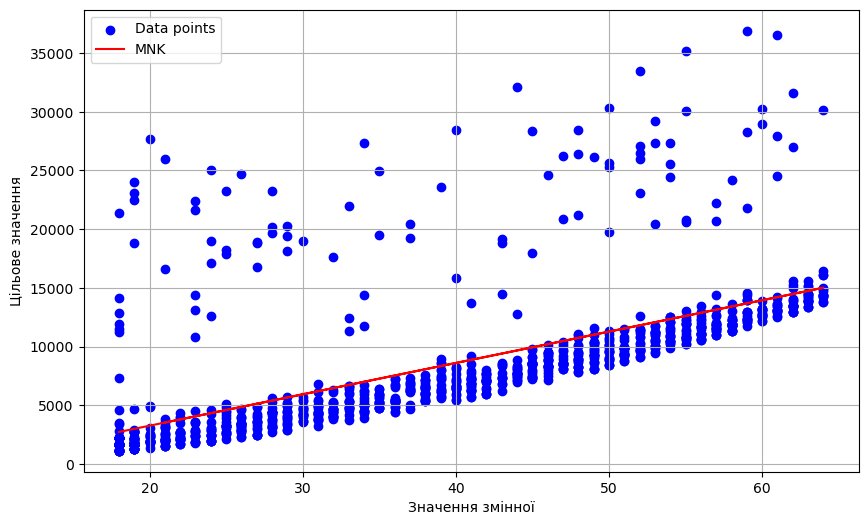

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(non_smoker_df["age"], non_smoker_df["charges"], color='blue', label='Data points')
plt.plot(non_smoker_df["age"], predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error
rmse_MNK = mean_squared_error(non_smoker_df["charges"], predictions_MNK, squared=False)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [22]:
print("MNK Coefs:", MNK_coefs)
print("MNK RMSE:", rmse_MNK)

MNK Coefs: [-2091.42055657   267.24891283]
MNK RMSE: 4662.505766636395


In [23]:
MNK_errors = non_smoker_df["charges"] - predictions_MNK
MNK_errors

1        -993.507574
2        -942.087003
3       15256.677043
4       -2593.689454
5       -2436.674141
            ...     
1332     -393.837911
1333     -670.476785
1334     -513.079074
1335    -1089.226374
1336    -1512.861613
Name: charges, Length: 1064, dtype: float64

---
2.
---

In [25]:
non_smoker_df["age"].shape

(1064,)

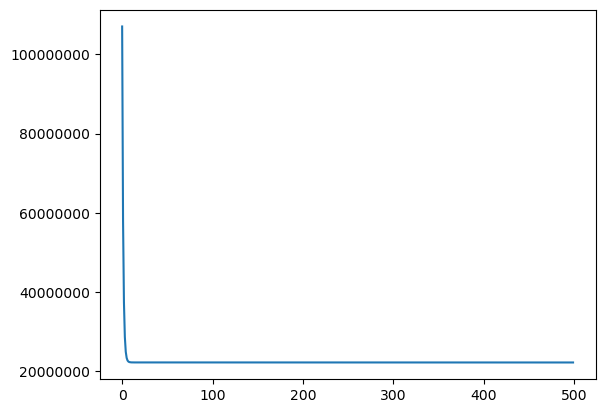

In [52]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0 
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        #errors.append(sum(error))
        errors.append(np.mean(np.square(error)))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

Reshaped_age = non_smoker_df["age"].values.reshape(-1, 1)
m, b, errors = full_batch_gradient_descent(Reshaped_age, non_smoker_df["charges"], lr=0.0001, epochs=500)
predictions_fbgd = m * non_smoker_df["age"] + b
plt.plot(errors);
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.show()

In [54]:
rmse_fbgd = mean_squared_error(non_smoker_df["charges"], predictions_fbgd, squared=False)
errors_fbgd = non_smoker_df["charges"] - predictions_fbgd
print("FBGD Coefs:", m, b)
print("FBGD RMSE:", rmse_fbgd)
errors_fbgd

FBGD Coefs: 220.57918226137932 -18.64622869286005
FBGD RMSE: 4714.406330819462


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


1       -2226.226752
2       -1708.108875
3       14724.003824
4       -3173.032404
5       -3062.686821
            ...     
1332      -39.786249
1333     -409.764584
1334    -1745.798252
1335    -2321.945552
1336    -2605.571599
Length: 1064, dtype: float64

In [48]:
errors[-5:]

[22135991.480386622,
 22135973.500466324,
 22135955.521360263,
 22135937.543068405,
 22135919.565590706]

---
3.
---

In [ ]:
!pip install scikit-learn --quiet

In [58]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(non_smoker_df["age"].to_frame(), non_smoker_df["charges"])
lin_reg.coef_, lin_reg.intercept_

predictions_sklearn = lin_reg.predict(non_smoker_df["age"].to_frame())
rmse_sklearn = mean_squared_error(non_smoker_df["charges"], predictions_sklearn, squared=False)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [60]:
print("sklearn Coefs:", lin_reg.coef_, lin_reg.intercept_)
print("sklearn RMSE:", rmse_sklearn)

sklearn Coefs: [267.24891283] -2091.4205565650827
sklearn RMSE: 4662.505766636395


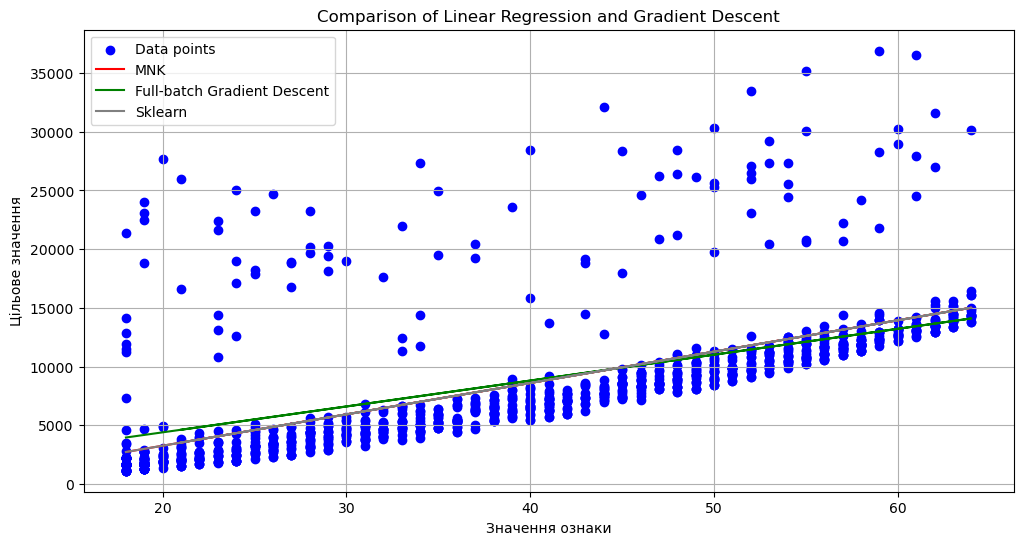

In [62]:
plt.figure(figsize=(12, 6))
plt.scatter(non_smoker_df["age"], non_smoker_df["charges"], color='blue', label='Data points')
plt.plot(non_smoker_df["age"], predictions_MNK, color='red', label='MNK')
plt.plot(non_smoker_df["age"], predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(non_smoker_df["age"], predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Модель градієнтного спуску трошки меньш точніша ніж модель методом найменших квадратів
Коефіцієнти вираховані моделлю близкі до підібраних вручну, але, звісно, набагато точніші

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [ ]:
smoker_df = medical_df[medical_df.smoker == 'yes']
sm_lin_reg = LinearRegression()

sm_lin_reg.fit(smoker_df["age"].to_frame(), smoker_df["charges"])

sm_predictions_sklearn = sm_lin_reg.predict(smoker_df["age"].to_frame())
sm_rmse_sklearn = mean_squared_error(smoker_df["charges"], sm_predictions_sklearn, squared=False)

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(smoker_df["age"], smoker_df["charges"], color='blue', label='Data points')
plt.plot(smoker_df["age"], sm_predictions_sklearn, color='grey', label='Sklearn')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("sklearn Coefs:", sm_lin_reg.coef_, sm_lin_reg.intercept_)
print("sklearn RMSE:", sm_rmse_sklearn)

In [ ]:
medical_df.charges.std()

**Висновки**
Досить великий RMSE відносно стандартного відхилення. Можливо, лінійна регрессія не найкраще підходить для передбачення цих даних. Як варіант, зрозуміти по якому признаку дані розділяються на дві групи, розділити і навчити дві моделі окремо. Або підібрати модель, яка краще впорається з цими даними